In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_learning_curve_overfitting


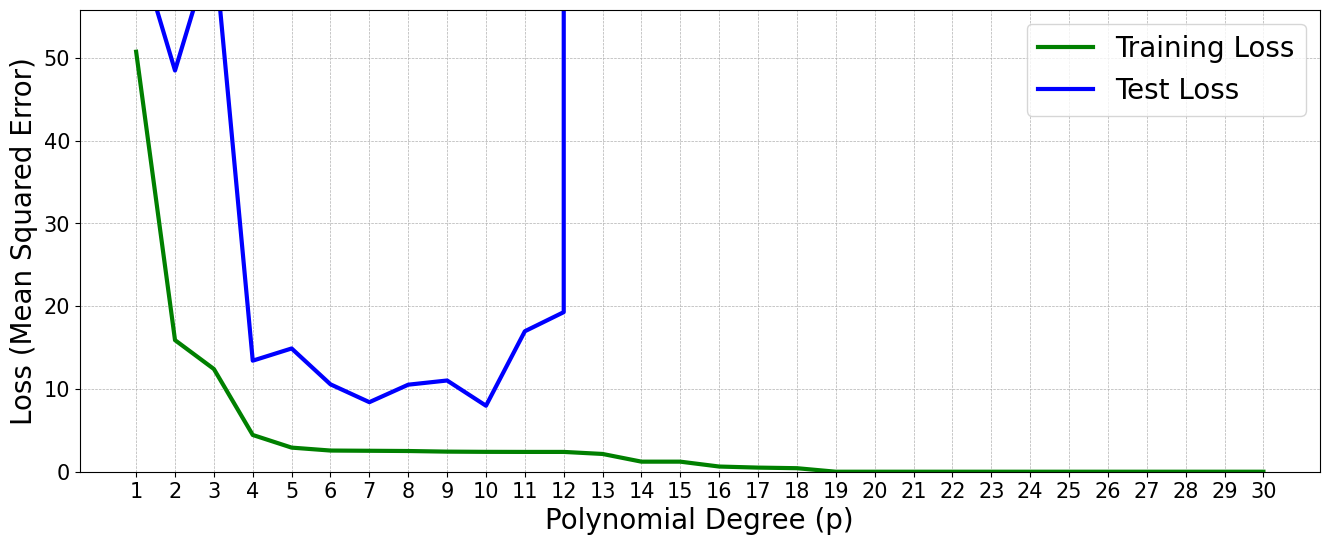

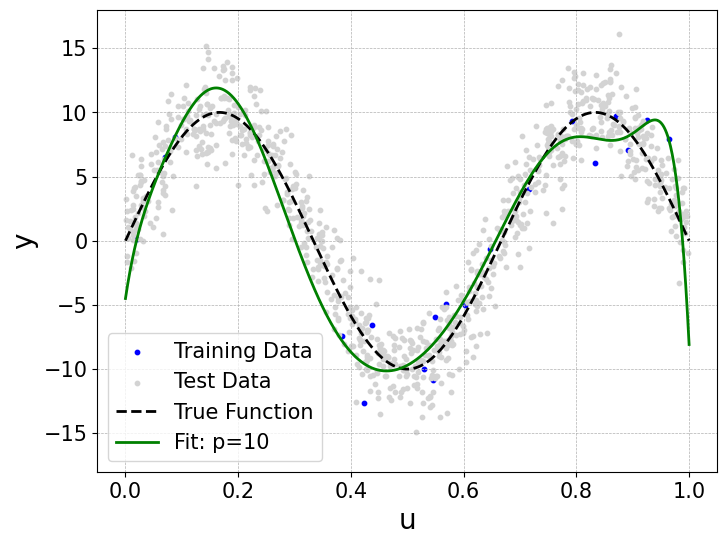

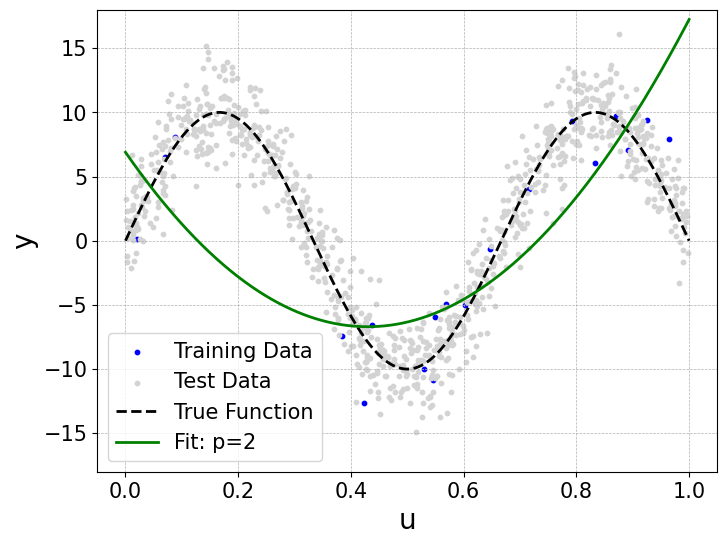

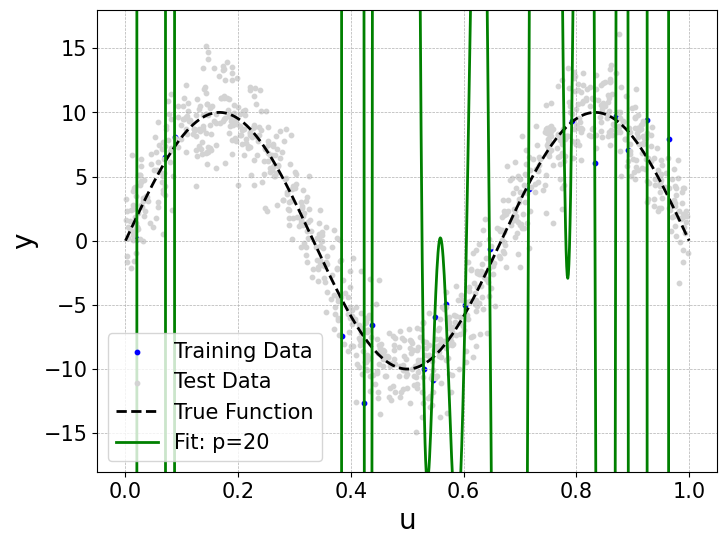

In [72]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
from pathlib import Path

# Define the true function
def true_function(u):
    return 10 * np.sin(3 * np.pi * u)

# Function to generate data points with a fixed random seed for reproducibility
def generate_data(n_points, seed):
    np.random.seed(seed)
    u = np.random.rand(n_points)
    y = true_function(u) + np.random.normal(0, 2, n_points)
    return u, y

# Function to compute loss (mean squared error)
def compute_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

# Polynomial functions
def poly_func(p, u):
    return p(u)

# Function to train models and calculate losses
def train_and_evaluate(train_size, test_size, degrees, seed):
    # Generate training and test data with the same seed for reproducibility
    u_train, y_train = generate_data(train_size, seed)
    u_test, y_test = generate_data(test_size, seed + 1)  # Different seed for test data

    # Store training and test losses
    train_losses = []
    test_losses = []
    best_degree = None
    best_poly = None

    # Iterate over polynomial degrees, fit the model, and calculate the losses
    for p in degrees:
        poly = Polynomial.fit(u_train, y_train, p)
        y_train_pred = poly_func(poly, u_train)
        y_test_pred = poly_func(poly, u_test)
        
        train_loss = compute_loss(y_train, y_train_pred)
        test_loss = compute_loss(y_test, y_test_pred)
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        
        # Track the polynomial with the best test error
        if best_degree is None or test_loss < test_losses[best_degree - 1]:
            best_degree = p
            best_poly = poly
    
    return train_losses, test_losses, best_degree, best_poly, u_train, y_train, u_test, y_test

# Function to plot a specific model for a given degree
def plot_model_for_degree(degree, poly, u_train, y_train, u_test, y_test, ylim=(-18, 18)):
    u_plot = np.linspace(0, 1, 1000)
    y_true_plot = true_function(u_plot)
    y_pred_plot = poly_func(poly, u_plot)

    # Plot the scatter data and the polynomial model
    plt.figure(figsize=(8, 6))
    plt.scatter(u_train, y_train, color='blue', label='Training Data', s=10)
    plt.scatter(u_test, y_test, color='lightgray', label='Test Data', s=10)
    plt.plot(u_plot, y_true_plot, 'k--', label='True Function', linewidth=2)  # Dotted black line for true function
    plt.plot(u_plot, y_pred_plot, color='green', label=f'Fit: p={degree}', linewidth=2)  # Solid green line for the fit
    plt.xlabel('u', fontsize=20)
    plt.ylabel('y', fontsize=20)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.legend(fontsize=15)
    plt.ylim(*ylim)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Save the figure using OUTPUT_DIR which is assumed to be defined already
    plt.savefig(str(OUTPUT_DIR / f'fit_p{degree}.png'), bbox_inches='tight', pad_inches=0)
    plt.show()

# Specify sizes for training and test sets
train_size = 20   # Number of training samples
test_size = 1000  # Number of test samples
random_seed = 0  # Random seed for reproducibility

# List of polynomial degrees from 1 to 30
degrees = list(range(1, 30 + 1))

# Train the model and get the losses and the best model
train_losses, test_losses, best_degree, best_poly, u_train, y_train, u_test, y_test = train_and_evaluate(train_size, test_size, degrees, random_seed)

# Determine y-axis limits based on training loss (scaled slightly to leave some margin)
min_loss = min(train_losses) * 0.9  # 10% margin below the lowest value
max_loss = max(train_losses) * 1.1  # 10% margin above the highest value

# Plot the learning curves (Training vs Test loss)
plt.figure(figsize=(16, 6))
plt.plot(degrees, train_losses, label='Training Loss', color='#008000', linewidth=3)  # Green for training loss
plt.plot(degrees, test_losses, label='Test Loss', color='#0000FF', linewidth=3)  # Blue for test loss
plt.xlabel('Polynomial Degree (p)', fontsize=20)
plt.ylabel('Loss (Mean Squared Error)', fontsize=20)
plt.xticks(degrees, fontsize=15)
plt.yticks(fontsize=15)
plt.ylim(min_loss, max_loss)  # Set y-axis limits based on training loss
plt.legend(fontsize=20)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Save the learning curve figure using OUTPUT_DIR which is assumed to be defined already
plt.savefig(str(OUTPUT_DIR / 'learning_curve.png'), bbox_inches='tight', pad_inches=0)
plt.show()

# Plot the best model found based on test error
plot_model_for_degree(best_degree, best_poly, u_train, y_train, u_test, y_test)

# Also plot models for some p's
# Fitting polynomials
polys = {}
for p in [2, 20]:
    polys[p] = Polynomial.fit(u_train, y_train, p)
    plot_model_for_degree(p, polys[p], u_train, y_train, u_test, y_test)